In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("all_matches.csv")
df.head()

,date,home_team,away_team,home_score,away_score,tournament,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Scotland,False


In [3]:
pd.unique(df[['home_team','away_team']].values.ravel())

array(['Scotland', 'England', 'Wales', 'Ireland', 'Uruguay', 'Argentina',
       'Austria', 'Hungary', 'Bohemia', 'Belgium', 'France',
       'Switzerland', 'Netherlands', 'British Guiana',
       'Trinidad and Tobago', 'South Africa', 'Germany', 'Sweden',
       'Norway', 'Denmark', 'Italy', 'Chile', 'Finland', 'Luxembourg',
       'Russia', 'Philippines', 'China', 'Brazil', 'Suriname',
       'United States', 'Japan', 'Paraguay', 'Egypt', 'Greece', 'Spain',
       'Czechoslovakia', 'Yugoslavia', 'Estonia', 'Northern Ireland',
       'Costa Rica', 'El Salvador', 'Guatemala', 'Honduras', 'Poland',
       'Portugal', 'Romania', 'New Zealand', 'Australia', 'Latvia',
       'Mexico', 'Lithuania', 'Turkey', 'Aruba', 'Curaçao', 'Bulgaria',
       'Canada', 'Soviet Union', 'Haiti', 'Jamaica', 'Kenya', 'Uganda',
       'Bolivia', 'Azerbaijan', 'Armenia', 'Georgia', 'Peru',
       'British Honduras', 'Dutch East Indies', 'Barbados', 'Nicaragua',
       'Cuba', 'Faroe Islands', 'Iceland', 'Mart

In [4]:
from Confederations import get_confederation

all_teams = pd.unique(df[['home_team', 'away_team']].values.ravel())
unknowns = [t for t in all_teams if get_confederation(t) == "Unknown"]
print(sorted(unknowns))

[]


In [5]:
def get_tournament_weight(tournament, home_team, away_team):
    t = tournament.strip()
    home_conf = get_confederation(home_team)
    away_conf = get_confederation(away_team)
    conf_priority = ["UEFA", "CONMEBOL", "CONCACAF", "CAF", "AFC", "OFC", "Unknown"]
    home_rank = conf_priority.index(home_conf)
    away_rank = conf_priority.index(away_conf)
    top_conf = home_conf if home_rank <= away_rank else away_conf

    # ── Tier 4.0 ──────────────────────────────────────────
    if t == "World Cup":
        return 4.0

    # ── Tier 3.0 ──────────────────────────────────────────
    if t in ["European Championship", "Copa America", "Copa América"]:
        return 3.0

    # ── Tier 2.5 ──────────────────────────────────────────
    if t in ["European Championship qual",
             "Copa America qualifier", "Copa América qualifier",
             "African Nations Cup", "Confederations Cup", "Olympic Games","Euro Ch q & Nordic Ch","Euro Ch q & British Ch","South American Champ","Mundialito"]:
        return 2.5

    if "European Nations League" in t and "CONCACAF" not in t:
        if "A" in t: return 2.5
        elif "B" in t: return 2.0
        elif "C" in t: return 1.75
        elif "D" in t: return 1.5
        else: return 2.5

    # ── Tier 2.0 ──────────────────────────────────────────
    if t == "World Cup qualifier":
        if top_conf in ["UEFA", "CONMEBOL"]: return 2.0
        elif top_conf == "CAF":              return 1.75
        elif top_conf == "CONCACAF":         return 1.75
        elif top_conf == "AFC":              return 1.5
        else:                                return 1.25  # OFC

    if t in ["African Nations Cup qualifier",
             "World Cup q & Nordic Ch", "World Cup q & British Ch",
             "NA Champ & WC qual", "World Cup and CONCACAF Ch q",
             "World Cup and Asian Cup qual", "World Cup and African Cup qual",
             "WC and Oce Cup q", "WC q and Oce Cup"]:
        return 2.0

    # ── Tier 1.75 ─────────────────────────────────────────
    if t in ["CONCACAF Championship", "Asian Cup",
             "CONCACAF Cup", "CONCACAF Series","Intercontinental Champ"]:
        return 1.75

    if "CONCACAF Nations League" in t:
        if "A" in t: return 1.75
        elif "B" in t: return 1.5
        elif "C" in t: return 1.25
        else: return 1.75

    # ── Tier 1.5 ──────────────────────────────────────────
    if t in ["Asian Cup qualifier", "CONCACAF Ch q",
             "Gulf Cup", "Arab Cup",
             "CECAFA Cup", "COSAFA Cup"]:
        return 1.5

    if t in ["Southeast Asian Champ", "South Asian Championship",
             "West Asian Championship", "East Asian Championship",
             "Central American Cup", "CFU Championship",
             "Copa Centenario", "Caribbean Cup",
             "Caribbean Championship","CONCACAF Ch q & Car Ch","CONCACAF Ch q & Car Ch PO","North American Champ","CONCACAF Ch & Car Ch q","Balkan & C European Champ"]:
        return 1.5

    # ── Tier 1.25 ─────────────────────────────────────────
    if t in ["Oceania Nations Cup", "Oceania Nations Cup qualifier",
             "Pacific Games", "Pacific Mini Games",
             "South Pacific Games", "South Pacific Mini Games",
             "Melanesian Cup", "Polynesian Cup"]:
        return 1.25

    # ── Keyword fallbacks ─────────────────────────────────
    t_lower = t.lower()

    if "qualifier" in t_lower or "qual" in t_lower:
        return 1.5

    if any(kw in t_lower for kw in ["championship", "cup", "tournament",
                                     "games", "friendly tournament"]):
        return 1.5

    # ── Tier 1.0 — Friendlies and everything else ─────────
    return 1.0
df['weight'] = df.apply(
    lambda row: get_tournament_weight(row['tournament'], row['home_team'], row['away_team']), 
    axis=1
)

In [6]:
df.groupby('tournament')['weight'].first().sort_values(ascending=False).tail(30)

tournament
CONCACAF Ch q & Car Ch PO        1.50
Friendship Games                 1.50
GANEFO Tournament                1.50
CONCACAF Ch q & Car Ch           1.50
CONCACAF Ch q & C Am Cup         1.50
Gossage Cup                      1.50
Dynasty Cup                      1.50
Pacific Mini Games               1.25
Pacific Games                    1.25
Oceania Nations Cup qualifier    1.25
Oceania Nations Cup              1.25
Melanesian Cup                   1.25
South Pacific Games              1.25
South Pacific Mini Games         1.25
Danube C & King Mihai C          1.00
Windward Islands Champ           1.00
Copa Cent Rev Mayo               1.00
Friendly                         1.00
Copa Circulo de la Prensa        1.00
FIFA Series                      1.00
Jakarta Anniversary Tourn        1.00
Copa Premio Honor Uruguayo       1.00
Artemio Franchi Trophy           1.00
Copa Ciudad de Mexico            1.00
Copa Paz del Chaco               1.00
Trans-Caucasian Champ            1.00
T

In [7]:
wc_qual = df[df['tournament'] == 'World Cup qualifier'][['home_team', 'away_team', 'weight']].sample(20, random_state=42)
print(wc_qual)

                     home_team            away_team  weight
35431                  Armenia                Spain    2.00
39080              South Korea           Uzbekistan    1.50
18790                    Japan            Hong Kong    1.50
20767                  Tunisia             Ethiopia    1.75
26548                 Paraguay              Uruguay    2.00
42948                  Czechia              Germany    2.00
43011                  Algeria               Zambia    1.75
23488                  Albania             Portugal    2.00
34393                  Ecuador              Bolivia    2.00
23551                   Angola             Zimbabwe    1.75
27889                    Ghana                Sudan    1.75
23697                    Kenya              Nigeria    1.75
31635                  England              Austria    2.00
40840  St Vincent & Grenadines               Guyana    1.75
42642              New Zealand                 Fiji    1.25
6850                Costa Rica  Trinidad

In [7]:
import importlib
import elo
importlib.reload(elo)
from elo import update_elo, get_elo, elo_ratings,apply_yearly_decay


df_sorted = df.sort_values('date').reset_index(drop=True)


In [8]:
df_sorted = df.sort_values('date').reset_index(drop=True)
home_elos = []
away_elos = []
current_year =None

for _, row in df_sorted.iterrows():
    match_year = int(row['date'][:4])
    if current_year is None:
        current_year=match_year
    if match_year>current_year:
        apply_yearly_decay(current_year)
        current_year=match_year
    home_elos.append(get_elo(row['home_team']))
    away_elos.append(get_elo(row['away_team']))
    update_elo(
        row['home_team'], row['away_team'],
        row['home_score'], row['away_score'],
        row['weight'], row['neutral']
    )

df_sorted['home_elo'] = home_elos
df_sorted['away_elo'] = away_elos
df_sorted['elo_diff'] = df_sorted['home_elo'] - df_sorted['away_elo']

if "West Germany" in elo_ratings:
    elo_ratings["Germany"] = max(elo_ratings.get("Germany", 0), elo_ratings["West Germany"])
    del elo_ratings["West Germany"]

if "Soviet Union" in elo_ratings:
    elo_ratings["Russia"] = max(elo_ratings.get("Russia", 0), elo_ratings["Soviet Union"])
    del elo_ratings["Soviet Union"]
    
elo_df = pd.DataFrame(list(elo_ratings.items()), columns=['team', 'elo'])
print(elo_df.sort_values('elo', ascending=False).head(20))

            team          elo
32         Spain  1760.146298
5      Argentina  1644.309846
10        France  1635.139892
1        England  1562.769645
166      Senegal  1544.966348
51        Turkey  1520.198277
87       Ecuador  1517.888530
44      Portugal  1514.338807
30         Japan  1508.829390
27        Brazil  1501.285755
84      Colombia  1493.152275
18        Norway  1489.572030
12   Netherlands  1483.796290
16       Germany  1467.907200
92       Croatia  1448.841294
49        Mexico  1439.651921
11   Switzerland  1420.602411
4        Uruguay  1417.703277
122      Nigeria  1413.742656
31      Paraguay  1411.834666


In [10]:
elo_df = pd.DataFrame(list(elo_ratings.items()), columns=['team', 'elo'])
print(elo_df.sort_values('elo', ascending=False).head(20))

            team          elo
32         Spain  1760.146298
5      Argentina  1644.309846
10        France  1635.139892
1        England  1562.769645
166      Senegal  1544.966348
51        Turkey  1520.198277
87       Ecuador  1517.888530
44      Portugal  1514.338807
30         Japan  1508.829390
27        Brazil  1501.285755
84      Colombia  1493.152275
18        Norway  1489.572030
12   Netherlands  1483.796290
16       Germany  1467.907200
92       Croatia  1448.841294
49        Mexico  1439.651921
11   Switzerland  1420.602411
4        Uruguay  1417.703277
122      Nigeria  1413.742656
31      Paraguay  1411.834666


In [11]:
def get_recent_form(team,past_df,n=10):
    team_matches=past_df[
        (past_df['home_team']==team)|
        (past_df['away_team']==team)
        ].tail(n)
    if len(team_matches)==0:
        return 0.5
    
    results =[]
    for _, match in team_matches.iterrows():
        if match['home_team']==team:
            if match['home_score'] >match['away_score']:results.append(1.0)
            elif match['home_score'] ==match['away_score']:results.append(0.5)
            else: results.append(0.0)
        else:
            if match['home_score'] <match['away_score']:results.append(1.0)
            elif match['home_score'] ==match['away_score']:results.append(0.5)
            else: results.append(0.0)
    weights = np.exp(np.linspace(-2, 0, len(results)))
    return np.average(results, weights=weights)

In [12]:
def get_h2h(home_team,away_team,past_df):
    h2h = past_df[
        ((past_df['home_team'] == home_team) & (past_df['away_team'] == away_team)) |
        ((past_df['home_team'] == away_team) & (past_df['away_team'] == home_team))
    ]
    if len(h2h) == 0:
        return 0.5
    wins = 0
    for _, match in h2h.iterrows():
        if match['home_team'] == home_team:
            if match['home_score'] > match['away_score']: wins += 1
        else:
            if match['away_score'] > match['home_score']:wins+=1
    return wins / len(h2h)

In [13]:
def get_attack_rating(team,past_df,n=10):
    matches=past_df[
        (past_df['home_team'] == team) |
        (past_df['away_team'] == team)
    ].tail(n)
    if len(matches)==0:
        return 1.5
    goals = []
    for _, match in matches.iterrows():
        if match['home_team'] == team:
            goals.append(match['home_score'])
        else:
            goals.append(match['away_score'])
    weights = np.exp(np.linspace(-2, 0, len(goals)))
    return np.average(goals, weights=weights)

def get_defence_rating(team, past_df, n=10):
    matches = past_df[
        (past_df['home_team'] == team) | 
        (past_df['away_team'] == team)
    ].tail(n)
    if len(matches) == 0:
        return 1.5  # league average default
    goals_conceded = []
    for _, match in matches.iterrows():
        if match['home_team'] == team:
            goals_conceded.append(match['away_score'])
        else:
            goals_conceded.append(match['home_score'])
    weights = np.exp(np.linspace(-2, 0, len(goals_conceded)))
    return np.average(goals_conceded, weights=weights)

    

In [14]:
from tqdm import tqdm

recent_form_home, recent_form_away = [], []
h2h_list = []
attack_home, attack_away = [], []
defence_home, defence_away = [], []

for i, row in tqdm(df_sorted.iterrows(), total=len(df_sorted)):
    past = df_sorted.iloc[:i]
    recent_form_home.append(get_recent_form(row['home_team'], past))
    recent_form_away.append(get_recent_form(row['away_team'], past))
    h2h_list.append(get_h2h(row['home_team'], row['away_team'], past))
    attack_home.append(get_attack_rating(row['home_team'], past))
    attack_away.append(get_attack_rating(row['away_team'], past))
    defence_home.append(get_defence_rating(row['home_team'], past))
    defence_away.append(get_defence_rating(row['away_team'], past))

df_sorted['recent_form_home'] = recent_form_home
df_sorted['recent_form_away'] = recent_form_away
df_sorted['h2h'] = h2h_list
df_sorted['attack_home'] = attack_home
df_sorted['attack_away'] = attack_away
df_sorted['defence_home'] = defence_home
df_sorted['defence_away'] = defence_away

df_sorted.to_csv('matches_with_features.csv', index=False)

100%|██████████| 51491/51491 [17:36<00:00, 48.74it/s] 


In [15]:
df_check = pd.read_csv('matches_with_features.csv')
print(df_check.shape)
print(df_check.columns.tolist())
print(df_check.isnull().sum())
print(df_check[['attack_home', 'attack_away', 'defence_home', 'defence_away']].head(10))

(51491, 19)
['date', 'home_team', 'away_team', 'home_score', 'away_score', 'tournament', 'country', 'neutral', 'weight', 'home_elo', 'away_elo', 'elo_diff', 'recent_form_home', 'recent_form_away', 'h2h', 'attack_home', 'attack_away', 'defence_home', 'defence_away']
date                0
home_team           0
away_team           0
home_score          0
away_score          0
tournament          0
country             0
neutral             0
weight              0
home_elo            0
away_elo            0
elo_diff            0
recent_form_home    0
recent_form_away    0
h2h                 0
attack_home         0
attack_away         0
defence_home        0
defence_away        0
dtype: int64
   attack_home  attack_away  defence_home  defence_away
0     1.500000     1.500000      1.500000      1.500000
1     0.000000     0.000000      0.000000      0.000000
2     1.761594     3.523188      3.523188      1.761594
3     1.644155     1.819939      1.819939      1.644155
4     1.858462     1.86

In [24]:
df = pd.read_csv('matches_with_features.csv')

df['result']=df.apply(lambda row: 2 if row['home_score']>row['away_score']
                    else(1 if row['home_score']==row['away_score']
                    else 0),axis=1)

df['home_advantage']=df['neutral'].apply(lambda x: 0 if x else 1)

df['attack_diff'] = df['attack_home'] - df['attack_away']
df['defence_diff'] = df['defence_away'] - df['defence_home']
df['form_diff'] = df['recent_form_home'] - df['recent_form_away']


features = ['elo_diff', 'form_diff', 'attack_diff', 'defence_diff',
            'h2h', 'weight', 'home_advantage']


train = df[(df['date'] >= '2000-01-01') & (df['date'] < '2018-01-01')]
test = df[df['date'] >= '2018-01-01']

X_train=train[features]
y_train=train['result']
X_test = test[features]
y_test = test['result']

print(f"Train: {len(X_train)} matches")
print(f"Test: {len(X_test)} matches")

Train: 17170 matches
Test: 8164 matches


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
import numpy as np

train = train.copy()
train['sample_weight']= np.exp(
    (pd.to_datetime(train['date']).rank()/len(train)) * 2
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model =LogisticRegression(max_iter=3000, class_weight='balanced')
model.fit(X_train_scaled,y_train,sample_weight=train['sample_weight'])
preds=model.predict(X_test_scaled)

print(f"LR Accuracy: {accuracy_score(y_test, preds):.4f}")

LR Accuracy: 0.6057


In [26]:
from xgboost import XGBClassifier
xgb_model=XGBClassifier(n_estimators=200 , max_depth=4, learning_rate=0.05,random_state=42,subsample=0.8,colsample_bytree=0.8)
xgb_model.fit(X_train, y_train,sample_weight=train['sample_weight'])

xgb_preds = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, xgb_preds):.4f}")

XGBoost Accuracy: 0.6524


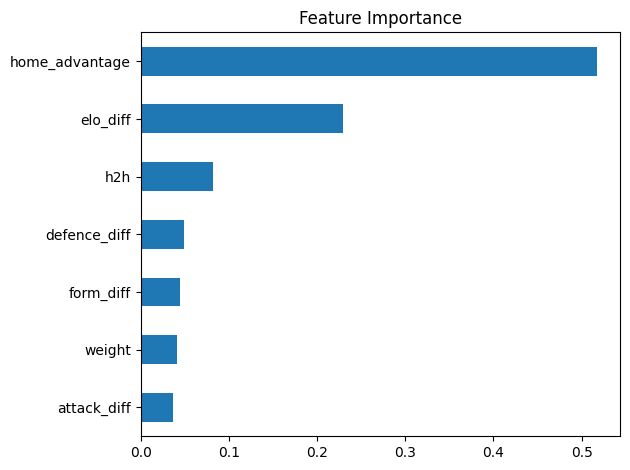

In [27]:
import matplotlib.pyplot as plt

feat_importance = pd.Series(xgb_model.feature_importances_, index=features)
feat_importance.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.tight_layout()
plt.show()

In [29]:
print(df['home_advantage'].value_counts())
print(df['neutral'].value_counts())

home_advantage
1    38025
0    13466
Name: count, dtype: int64
neutral
False    38025
True     13466
Name: count, dtype: int64


In [ ]:
features_no_home = ['elo_diff', 'recent_form_home', 'recent_form_away', 'h2h', 'weight']
xgb_no_home = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_no_home.fit(X_train[features_no_home], y_train)
preds_no_home = xgb_no_home.predict(X_test[features_no_home])
print(f"Without home advantage: {accuracy_score(y_test, preds_no_home):.4f}")

In [31]:
lr_probs =model.predict_proba(X_test)
print("Classes:",model.classes_)
print("Sample probabilities:")
print(lr_probs[:5])

Classes: [0 1 2]
Sample probabilities:
[[6.67285882e-026 3.24808183e-013 1.00000000e+000]
 [4.68720600e-060 2.07418492e-030 1.00000000e+000]
 [9.99983516e-001 1.64840019e-005 9.47519881e-011]
 [1.00000000e+000 4.63829577e-093 3.41616393e-187]
 [8.94025914e-070 2.71591802e-035 1.00000000e+000]]


/home/noir/Desktop/projects/World-Cup-Predictor/venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [32]:
wc2022=df[(df['tournament'] == 'World Cup') &
          (df['date'] >= '2022-11-01') &
          (df['date'] <= '2022-12-31')].copy()
print(f"WC 2022 matches: {len(wc2022)}")

wc2022['home_advantage'] = wc2022.apply(
    lambda row: 1 if row['home_team'] == 'Qatar' else 0, axis=1
)

X_wc2022 = wc2022[features]
y_wc2022=wc2022['result']

wc2022_preds=xgb_model.predict(X_wc2022)
wc2022_probs=xgb_model.predict_proba(X_wc2022)

print(f"WC 2022 Accuracy: {accuracy_score(y_wc2022, wc2022_preds):.4f}")

WC 2022 matches: 64
WC 2022 Accuracy: 0.7188


In [23]:
wc2022['predicted'] = wc2022_preds
wc2022['correct'] = wc2022['predicted'] == wc2022['result']

wrong = wc2022[wc2022['correct'] == False][['date', 'home_team', 'away_team', 'result', 'predicted']]
print(wrong)

             date      home_team      away_team  result  predicted
47764  2022-11-20          Qatar        Ecuador       0          1
47769  2022-11-21  United States          Wales       1          2
47773  2022-11-22   Saudi Arabia      Argentina       2          1
47774  2022-11-22        Denmark        Tunisia       1          2
47775  2022-11-22         Mexico         Poland       1          2
47777  2022-11-23        Croatia        Morocco       1          2
47784  2022-11-24    South Korea        Uruguay       1          2
47787  2022-11-25          Qatar        Senegal       0          2
47788  2022-11-25        England  United States       1          2
47789  2022-11-25        Ecuador    Netherlands       1          2
47796  2022-11-27        Germany          Spain       1          2
47801  2022-11-28       Cameroon         Serbia       1          2
47809  2022-11-30        Tunisia         France       2          1
47812  2022-12-01          Japan          Spain       2       